<a href="https://colab.research.google.com/github/Sanjyot19h/Research-Paper-Training-Models/blob/main/paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = '/content/drive/MyDrive/archive (4).zip'

In [ ]:
import zipfile
import os

extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['CT-Scan images', 'ct_scan.csv']


In [ ]:
import os

for root, dirs, files in os.walk('/content/data'):
    print(root)

/content/data
/content/data/CT-Scan images
/content/data/CT-Scan images/CT-Scan images
/content/data/CT-Scan images/CT-Scan images/CT-Scan Images
/content/data/CT-Scan images/CT-Scan images/CT-Scan Images/Non-Cancerous raw images - jpg
/content/data/CT-Scan images/CT-Scan images/CT-Scan Images/Cancerous raw images-jpg


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    '/content/data',
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    '/content/data',
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)


Found 292 images belonging to 1 classes.
Found 72 images belonging to 1 classes.


In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_eff = Model(inputs=base_model.input, outputs=output)

model_eff.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9726 - loss: 0.0597 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 2.3067e-06 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 1.0000 - loss: 1.4356e-06 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 2.6180e-07 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 1.0000 - loss: 4.0852e-07 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.8065e-07 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 824ms/step - accuracy: 1.0000 - loss: 1.0267e-06 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.6918e-07 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 1.0000 - lo

In [ ]:
base_model2 = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model2.layers:
    layer.trainable = False

x = base_model2.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_res = Model(inputs=base_model2.input, outputs=output)

model_res.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

history_res = model_res.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 1.0000 - loss: 0.0138 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 3.0462e-07 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 1.0000 - loss: 1.5943e-07 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 3.8371e-08 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 1.0000 - loss: 5.6963e-08 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 2.7052e-08 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 1.0000 - loss: 8.8271e-08 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 2.5944e-08 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s

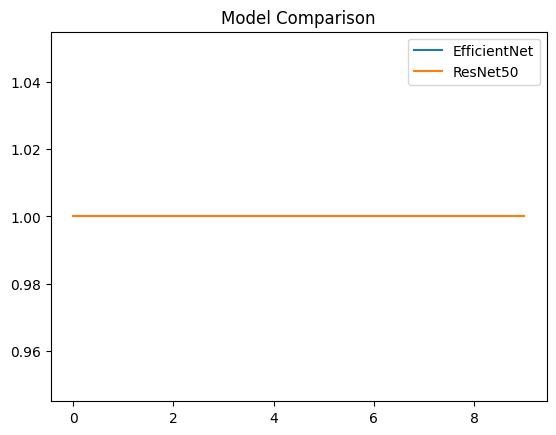

In [ ]:
plt.plot(history_eff.history['val_accuracy'], label='EfficientNet')
plt.plot(history_res.history['val_accuracy'], label='ResNet50')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
dataset_path = '/content/data/CT-Scan images/CT-Scan images/CT-Scan Images'

In [ ]:
import os

print("Exists:", os.path.exists(dataset_path))
print("Is Directory:", os.path.isdir(dataset_path))
print("Inside:", os.listdir(dataset_path))


Exists: True
Is Directory: True
Inside: ['Non-Cancerous raw images - jpg', 'Cancerous raw images-jpg']


In [ ]:
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):  # ignore anything weird
        print(folder, ":", len(os.listdir(folder_path)))


Non-Cancerous raw images - jpg : 126
Cancerous raw images-jpg : 238


In [ ]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 292 images belonging to 2 classes.
Found 72 images belonging to 2 classes.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,   # ⚠️ use correct path here
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 292 images belonging to 2 classes.
Found 72 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.7643979057591623), 1: np.float64(1.4455445544554455)}


In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 993ms/step - accuracy: 0.4897 - loss: 1.8604 - precision: 0.3554 - recall: 0.5842 - val_accuracy: 0.3472 - val_loss: 0.6959 - val_precision: 0.3472 - val_recall: 1.0000
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 966ms/step - accuracy: 0.3459 - loss: 0.6933 - precision: 0.3459 - recall: 1.0000 - val_accuracy: 0.3472 - val_loss: 0.6969 - val_precision: 0.3472 - val_recall: 1.0000
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 867ms/step - accuracy: 0.3459 - loss: 0.6933 - precision: 0.3459 - recall: 1.0000 - val_accuracy: 0.3472 - val_loss: 0.6969 - val_precision: 0.3472 - val_recall: 1.0000
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 923ms/step - accuracy: 0.3459 - loss: 0.6932 - precision: 0.3459 - recall: 1.0000 - val_accuracy: 0.3472 - val_loss: 0.6965 - val_precision: 0.3472 - val_recall: 1.0000
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 868ms/step - accuracy: 0.3459 - loss: 0.6932 - precision: 0.3459 - recall: 1.0000 - val_accuracy: 0.3472 - val_los

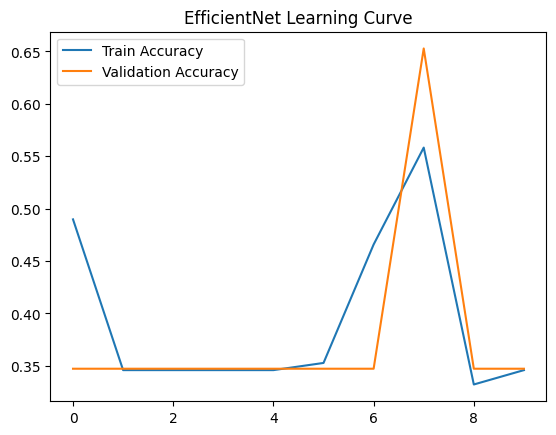

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("EfficientNet Learning Curve")
plt.show()

In [ ]:
import numpy as np

preds = model_eff.predict(val_data)
print(np.unique((preds > 0.5).astype(int)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
[1]


In [ ]:
import numpy as np

unique, counts = np.unique(train_data.classes, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(191), np.int32(1): np.int64(101)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_eff = Model(inputs=base_model.input, outputs=output)

In [ ]:
for layer in base_model.layers:
    layer.trainable = True

In [ ]:
from tensorflow.keras.optimizers import Adam

model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),   # 🔥 LOW LR is key
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    class_weight=class_weights
)


Epoch 1/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.5171 - loss: 0.6940 - val_accuracy: 0.6528 - val_loss: 0.6921
Epoch 2/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7671 - loss: 0.6020 - val_accuracy: 0.6528 - val_loss: 0.6821
Epoch 3/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8493 - loss: 0.5245 - val_accuracy: 0.6528 - val_loss: 0.6825
Epoch 4/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.8630 - loss: 0.4789 - val_accuracy: 0.6250 - val_loss: 0.6896
Epoch 5/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9007 - loss: 0.4180 - val_accuracy: 0.5139 - val_loss: 0.6919
Epoch 6/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.9418 - loss: 0.3498 - val_accuracy: 0.4028 - val_loss: 0.6930
Epoch 7/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.9349 - loss: 0.3191 - val_accuracy: 0.3611 - val_loss: 0.6963
Epoch 8/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9589 - loss: 0.2578 - val_accuracy: 0.3750 - val_loss

In [ ]:
import numpy as np

preds = model_eff.predict(val_data)
print(np.unique((preds > 0.5).astype(int)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
[0 1]


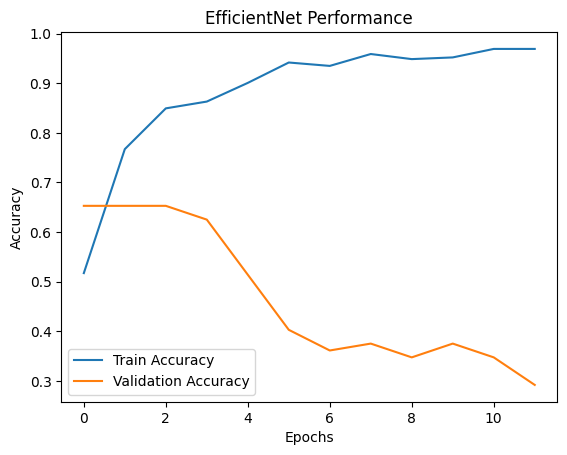

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("EfficientNet Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

val_data.reset()

y_true = val_data.classes
y_pred = (model_eff.predict(val_data) > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step
[[ 6 41]
 [ 2 23]]
              precision    recall  f1-score   support

           0       0.75      0.13      0.22        47
           1       0.36      0.92      0.52        25

    accuracy                           0.40        72
   macro avg       0.55      0.52      0.37        72
weighted avg       0.61      0.40      0.32        72



In [ ]:
history_res = model_res.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.4726 - loss: 1.9176 - precision_1: 0.3613 - recall_1: 0.6832 - val_accuracy: 0.3472 - val_loss: 0.7858 - val_precision_1: 0.3472 - val_recall_1: 1.0000
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6199 - loss: 0.6716 - precision_1: 0.4545 - recall_1: 0.4950 - val_accuracy: 0.8750 - val_loss: 0.6448 - val_precision_1: 0.7353 - val_recall_1: 1.0000
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7123 - loss: 0.6308 - precision_1: 0.5563 - recall_1: 0.8317 - val_accuracy: 0.7083 - val_loss: 0.6334 - val_precision_1: 0.5435 - val_recall_1: 1.0000
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6884 - loss: 0.6091 - precision_1: 0.5272 - recall_1: 0.9604 - val_accuracy: 0.7778 - val_loss: 0.5955 - val_precision_1: 0.6098 - val_recall_1: 1.0000
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7637 - loss: 0.5784 - precision_1: 0.6081 - recall_1: 0.8911 - val_accur

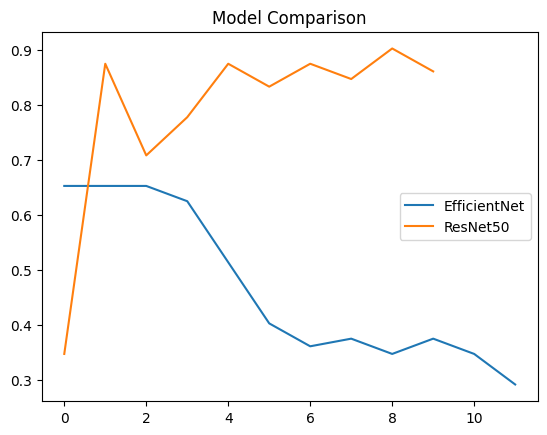

In [ ]:
plt.plot(history_eff.history['val_accuracy'], label='EfficientNet')
plt.plot(history_res.history['val_accuracy'], label='ResNet50')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
class_weights = {0: 1.0, 1: 2.5}


In [ ]:
y_pred = (model_eff.predict(val_data) > 0.3).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 799ms/step


In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9863 - loss: 0.1935 - val_accuracy: 0.6389 - val_loss: 0.6738
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9623 - loss: 0.1983 - val_accuracy: 0.6806 - val_loss: 0.6636
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9829 - loss: 0.1589 - val_accuracy: 0.6528 - val_loss: 0.6696
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.9760 - loss: 0.1678 - val_accuracy: 0.6944 - val_loss: 0.6766
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.9829 - loss: 0.1441 - val_accuracy: 0.6667 - val_loss: 0.6723
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9863 - loss: 0.1464 - val_accuracy: 0.5556 - val_loss: 0.6809
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9829 - loss: 0.1303 - val_accuracy: 0.5833 - val_loss: 0.6771
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9932 - loss: 0.1063 - val_accuracy: 0.6806 - val_loss:

In [ ]:
val_data.reset()

In [ ]:
import numpy as np

y_pred = (model_eff.predict(val_data) > 0.3).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = val_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[28 19]
 [18  7]]
              precision    recall  f1-score   support

           0       0.61      0.60      0.60        47
           1       0.27      0.28      0.27        25

    accuracy                           0.49        72
   macro avg       0.44      0.44      0.44        72
weighted avg       0.49      0.49      0.49        72



In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9932 - loss: 0.0410 - val_accuracy: 1.0000 - val_loss: 0.0949
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9966 - loss: 0.0531 - val_accuracy: 1.0000 - val_loss: 0.0832
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9966 - loss: 0.0310 - val_accuracy: 1.0000 - val_loss: 0.1463
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9966 - loss: 0.0429 - val_accuracy: 1.0000 - val_loss: 0.0487
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9966 - loss: 0.0365 - val_accuracy: 1.0000 - val_loss: 0.0394
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 1.0000 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0471
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0352
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9966 - loss: 0.0261 - val_accuracy: 1.0000 - val_loss: 0.0282


In [ ]:
val_data.reset()

y_pred = (model_eff.predict(val_data) > 0.35).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 989ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = val_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[30 17]
 [17  8]]
              precision    recall  f1-score   support

           0       0.64      0.64      0.64        47
           1       0.32      0.32      0.32        25

    accuracy                           0.53        72
   macro avg       0.48      0.48      0.48        72
weighted avg       0.53      0.53      0.53        72



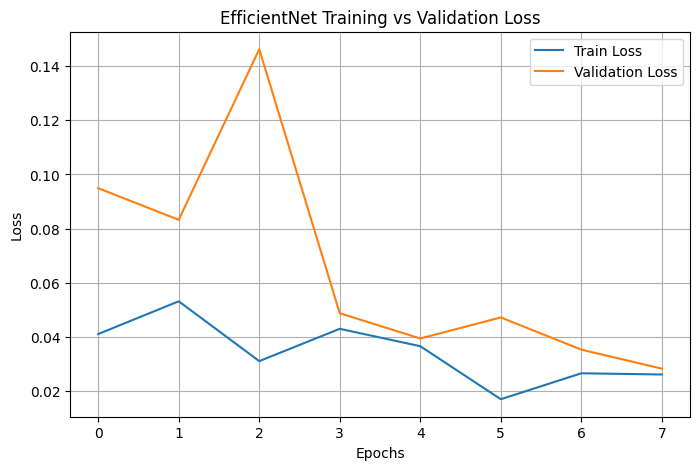

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Validation Loss')

plt.title("EfficientNet Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()